# `Maranatha.jl` :: Filter and Rebuild Results

This notebook demonstrates how to remove selected resolution points
from a previously generated quadrature dataset and rebuild a filtered
result file for further analysis.

This workflow is useful when:

- certain low- or high-resolution points should be excluded
- you want to test the stability of the extrapolation fit
- some datapoints are considered unsuitable for a specific analysis
- you want to rebuild a cleaner dataset without rerunning the full computation

The overall workflow is:

1. Generate or locate a saved result file
2. Remove selected `nsamples` from the file
3. Load the filtered dataset
4. Inspect the remaining datapoints
5. Perform fitting and visualization again

## Initialize Julia environment

First we configure the Julia runtime and load the
**`Maranatha.jl`** package.

In [1]:
ENV["JULIA_NUM_THREADS"] = get(ENV, "JULIA_NUM_THREADS", "4")

using Maranatha


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## Generate the original dataset

To demonstrate the filtering workflow, we first generate
a standard quadrature dataset using the TOML-based interface.

This step creates the saved JLD2 result file that will later
be modified by removing selected resolution points.

As in the earlier notebooks, the same dataset could also be
generated directly from Julia code instead of a TOML file.

In [2]:
run_result = run_Maranatha("../samples/sample_1d.toml")

(a = 0.0, b = 3.141592653589793, h = [1.5707963267948966, 1.0471975511965976, 0.7853981633974483, 0.6283185307179586, 0.5235987755982988, 0.4487989505128276, 0.39269908169872414, 0.3490658503988659], avg = [1.9999999543942306, 1.9999999983080423, 1.999999999833522, 1.9999999999722917, 1.9999999999935836, 1.9999999999981357, 1.9999999999993603, 1.9999999999997509], err = NamedTuple[(ks = [8, 10, 12], coeffs = [1.124788539770296e-9, 1.4753719807192386e-10, 3.815912407242014e-12], derivatives = [1.0, -1.0, 1.0], terms = [6.548619787330988e-8, -2.119435374676256e-8, 1.3525608060986144e-9], total = 4.5644404932645934e-8, center = 1.5707963267948966, h = 1.5707963267948966), (ks = [8, 10, 12], coeffs = [1.6871828099521367e-9, 5.728022157904421e-10, 5.0364674597331475e-11], derivatives = [1.0, -1.0, 1.0], terms = [2.5551694343111364e-9, -9.51304359599064e-10, 9.172718506231512e-11], total = 1.6955922597743876e-9, center = 1.5707963267948966, h = 1.0471975511965976), (ks = [8, 10, 12], coeffs 

## Reconstruct the saved result filename

Next we define the metadata needed to identify the saved
quadrature result file.

These values must match the dataset that was generated above,
so that the correct JLD2 file can be located and modified.

In [3]:
ns = [2, 3, 4, 5, 6, 7, 8, 9]
save_path = :"."
result_string = "1D"
rule = :gauss_p4
boundary = :LU_EXEX

Nstr = join(sort(ns), "_")
run_result_file = joinpath(
    save_path,
    "result_$(result_string)_$(rule)_$(boundary)_N_$(Nstr).jld2"
)

"./result_1D_gauss_p4_LU_EXEX_N_2_3_4_5_6_7_8_9.jld2"

## Remove selected resolution points

The function `drop_nsamples_from_file` creates a new filtered
result file by removing specific resolution points from an
existing dataset.

In this example we remove the datapoints corresponding to
`N = 2` and `N = 3`.

This is useful when testing how sensitive the extrapolation
is to coarse-grid points or when rebuilding a dataset with
a different fitting range.

In [4]:
run_result_filtered_file = drop_nsamples_from_file(
    run_result_file,
    [2, 3];
    write_summary = true,
    output_dir = ".",
    name_prefix = "filtered"
)

"./result_filtered_gauss_p4_LU_EXEX_N_4_5_6_7_8_9.jld2"

## Load the filtered dataset

After filtering, we load the rebuilt JLD2 file back into Julia.

The filtered result has the same structure as a standard
`run_Maranatha` output, so it can be analyzed using the
usual plotting and fitting routines.

In [5]:
run_result_filtered = load_datapoint_results(run_result_filtered_file)

(a = 0.0, b = 3.141592653589793, h = [0.7853981633974483, 0.6283185307179586, 0.5235987755982988, 0.4487989505128276, 0.39269908169872414, 0.3490658503988659], avg = [1.9999999998335218, 1.9999999999722913, 1.9999999999935836, 1.9999999999981353, 1.9999999999993598, 1.9999999999997509], err = [(ks = [8, 10, 12], coeffs = [2.2495770819334088e-9, 1.4198629360317195e-9, 2.489014012043227e-10], derivatives = [1.0, -1.0, 1.0], terms = [2.558054607147103e-10, -9.959444540804312e-11, 1.0769506414246399e-11], total = 1.669805217209136e-10, center = 1.5707963267948966, h = 0.7853981633974483), (ks = [8, 10, 12], coeffs = [2.811971365457476e-9, 2.8293179274730013e-9, 8.141204091629378e-10], derivatives = [1.0, -1.0, 1.0], terms = [4.291703488293286e-11, -1.7047484464908643e-11, 1.936542046313519e-12], total = 2.7806092464337738e-11, center = 1.5707963267948966, h = 0.6283185307179586), (ks = [8, 10, 11], coeffs = [3.3743656926855604e-9, 4.941765760435297e-9, -4.556951968960078e-19], derivatives 

## Inspect the filtered datapoints

Before performing the final fit, it is often useful to inspect
the remaining datapoints directly.

Here we plot the filtered dataset itself, which helps verify

- which points remain after filtering
- how the estimates and error bars are distributed
- whether the retained resolution range looks suitable for fitting

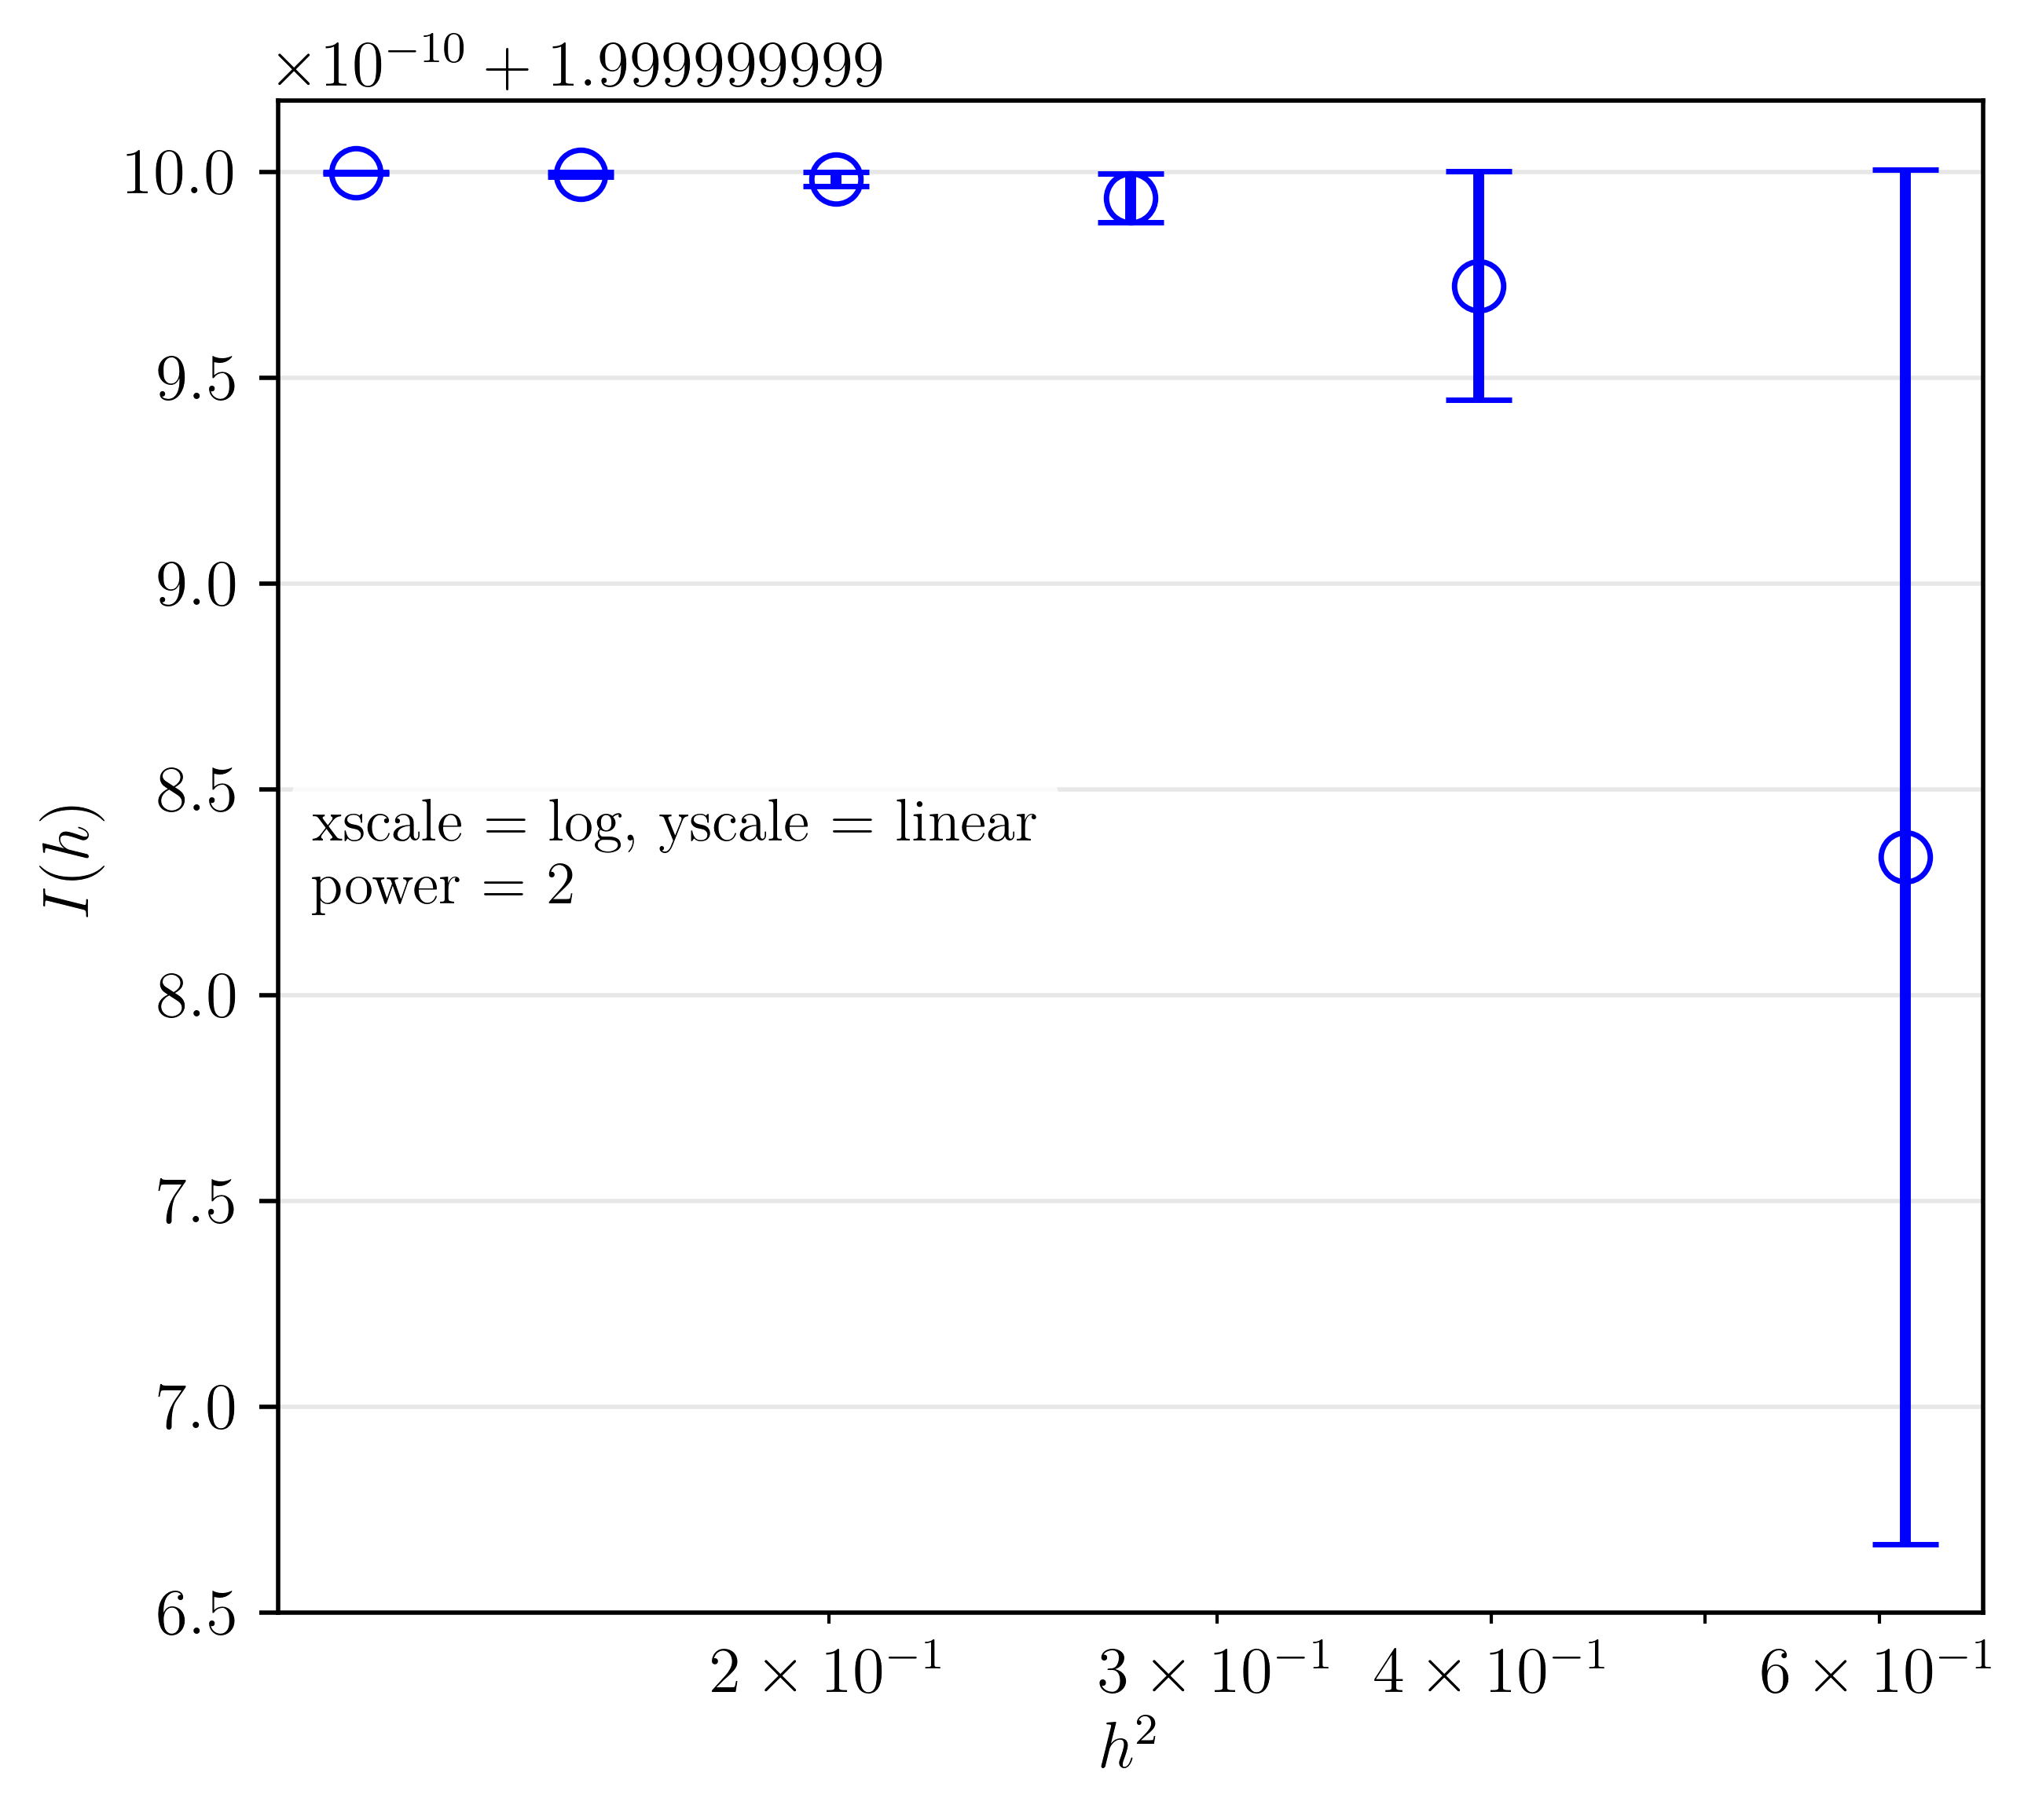

In [6]:
plot_datapoints_result(
    run_result_filtered;
    name = run_result_filtered_file,
    h_power = 2,
    xscale = :log,
    yscale = :linear,
    rule = run_result_filtered.rule,
    boundary = run_result_filtered.boundary,
)

## Refit the filtered dataset

Now we perform the continuum extrapolation again using the
filtered dataset.

This allows us to compare how the fit changes after removing
selected resolution points from the original data.

In [7]:
fit_result_filtered = least_chi_square_fit(
    run_result_filtered;
    nterms=4, 
    ff_shift=0, 
    nerr_terms=3
)

print_fit_result(fit_result_filtered)

[2026-03-08 22:02:02.560] residual ks (backend) = [8, 9, 10, 11], fit powers (h^p), ff_shift=0 = [8, 9, 10]
[2026-03-08 22:02:04.199]            λ_0 = 2.00000000000000(72)
[2026-03-08 22:02:04.199]            λ_1 = -0.000000001(16) *
[2026-03-08 22:02:04.199]            λ_2 = 0.000000000(54) *
[2026-03-08 22:02:04.200]            λ_3 = -0.000000000(43) *
[2026-03-08 22:02:04.200] 
[2026-03-08 22:02:04.200] Chi^2 / d.o.f. = 3.199312279606e-05 / 2 = 1.599656139803e-05
[2026-03-08 22:02:04.200] Result (h→0)   = 2.00000000000000(72)
[2026-03-08 22:02:04.200] 


## Visualize convergence after filtering

Finally we plot the convergence behaviour of the filtered dataset
together with the extrapolated continuum result.

This makes it easier to assess whether removing the selected
datapoints improves, stabilizes, or significantly changes
the final fit.

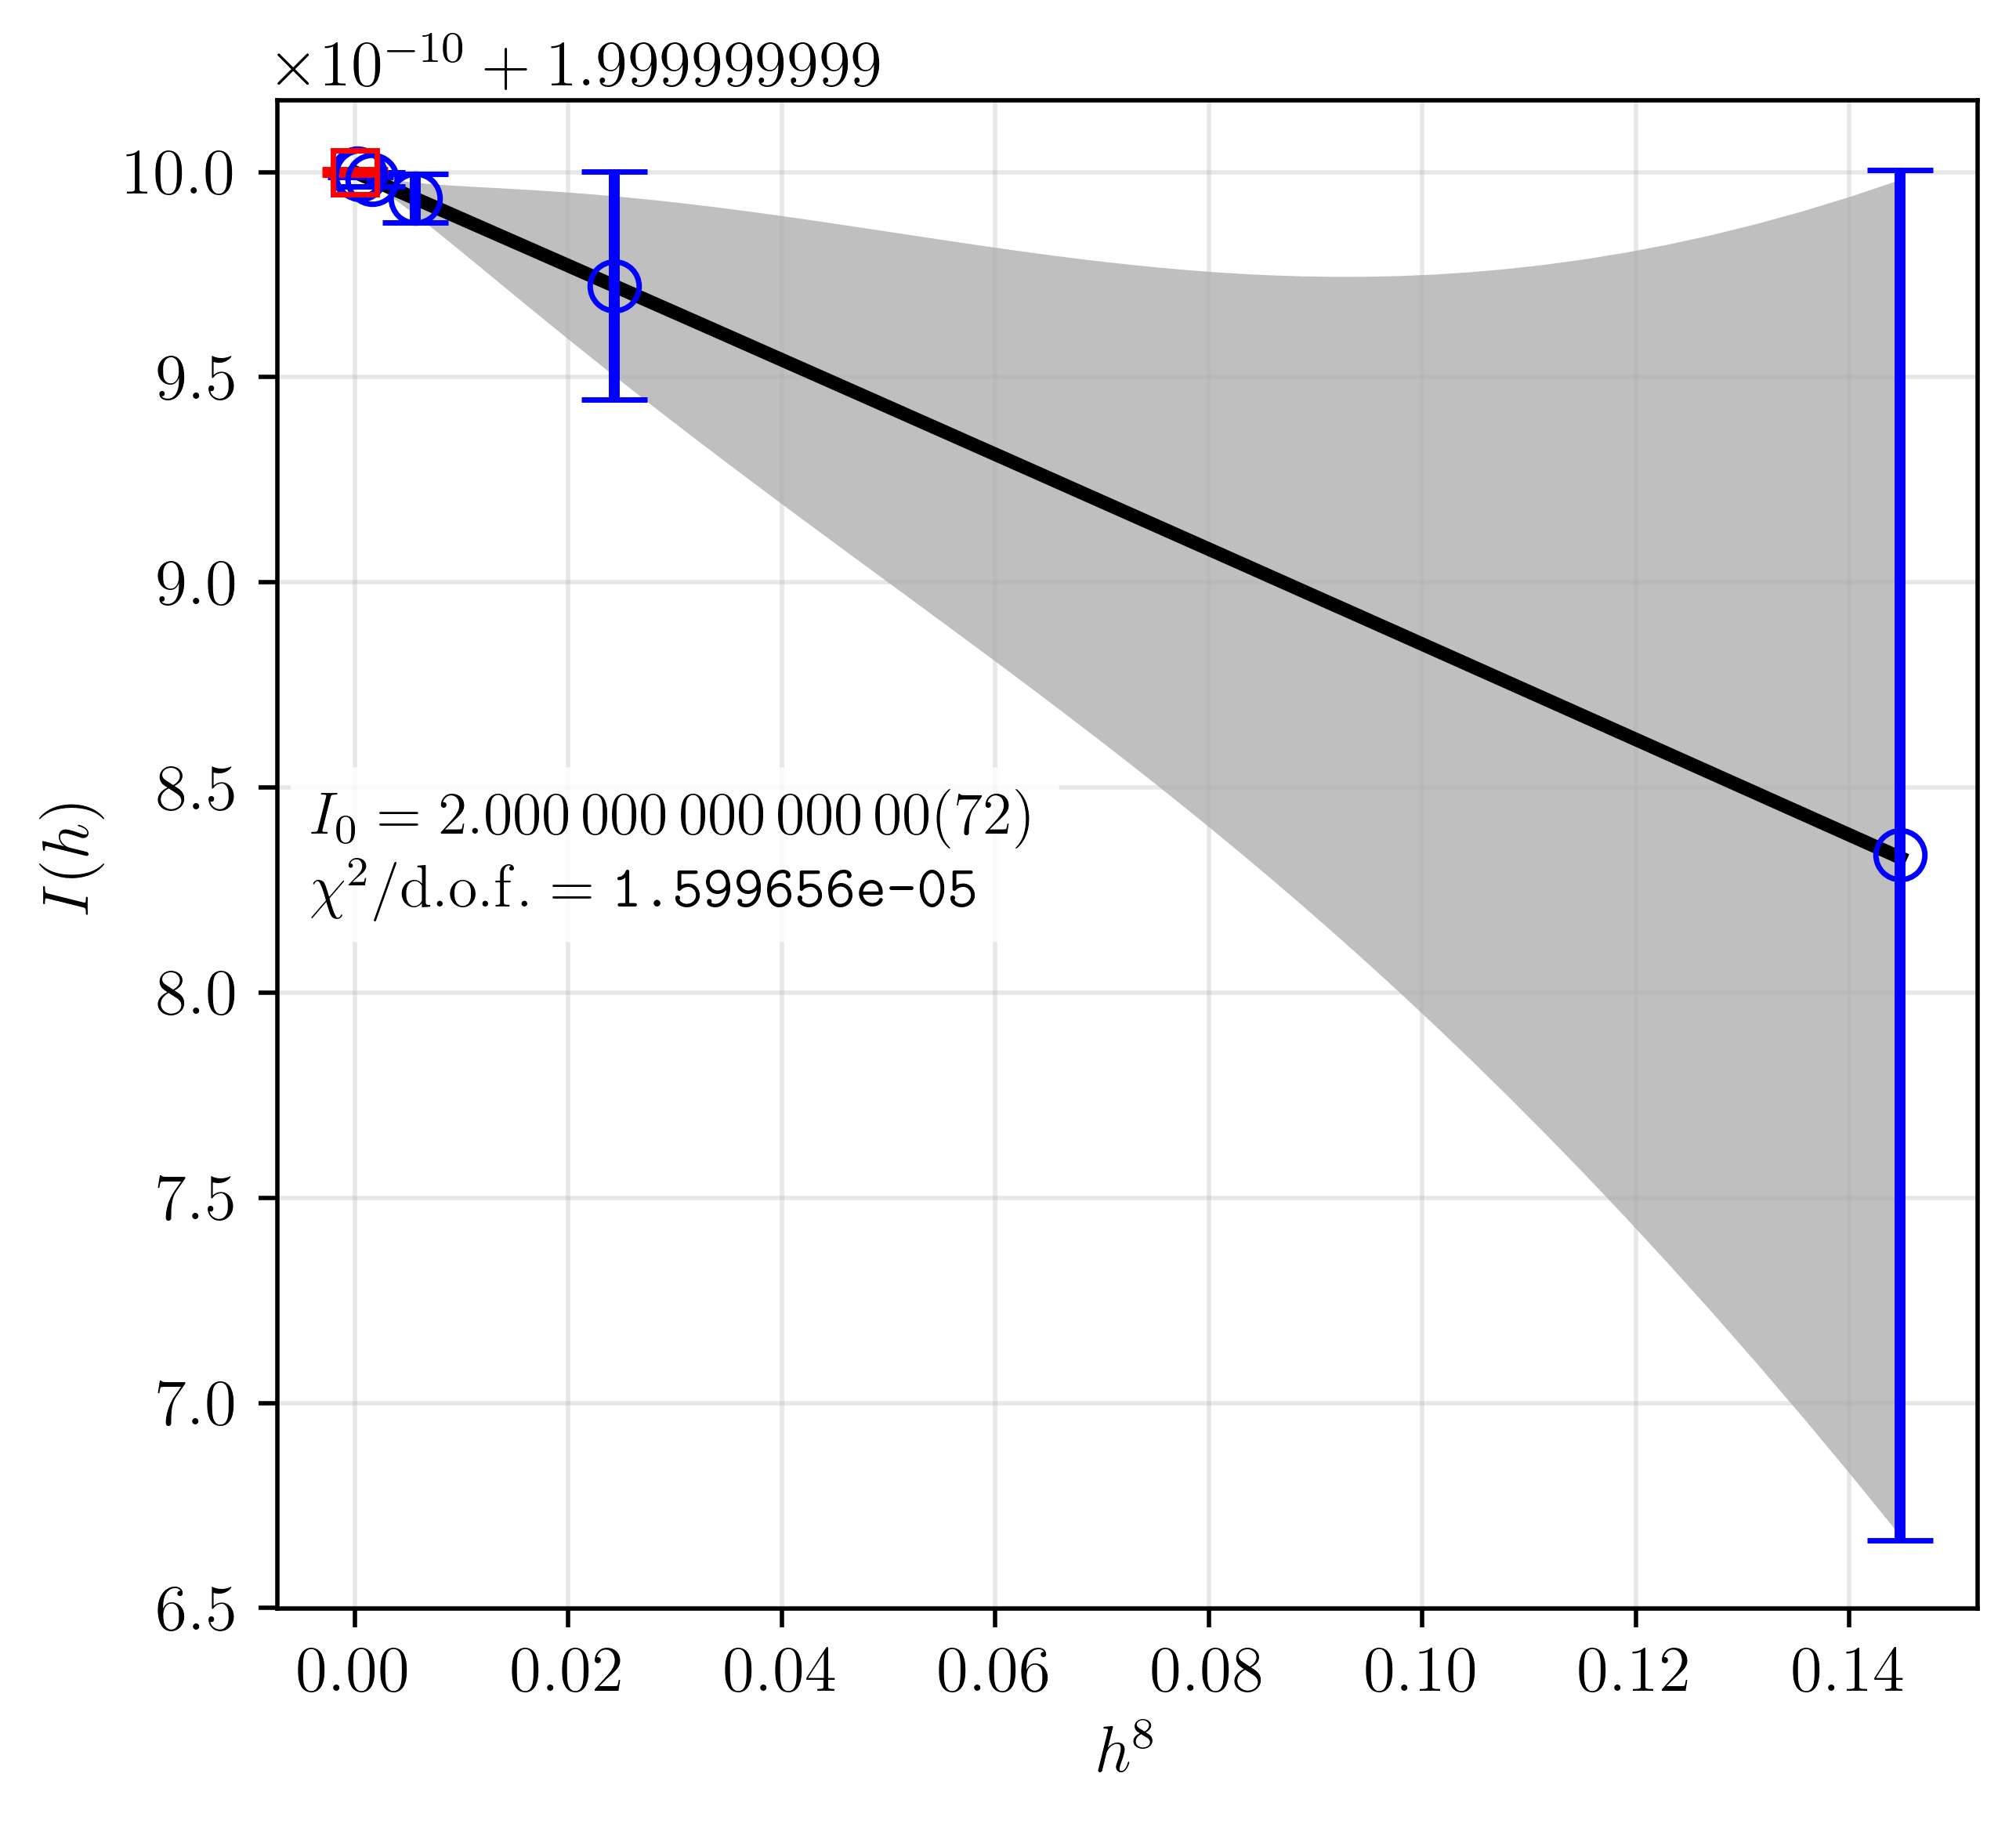

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `./result_Maranatha_test4_gauss_p4_LU_EXEX_extrap-crop.pdf'.
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `./result_Maranatha_test4_gauss_p4_LU_EXEX_reldiff-crop.pdf'.


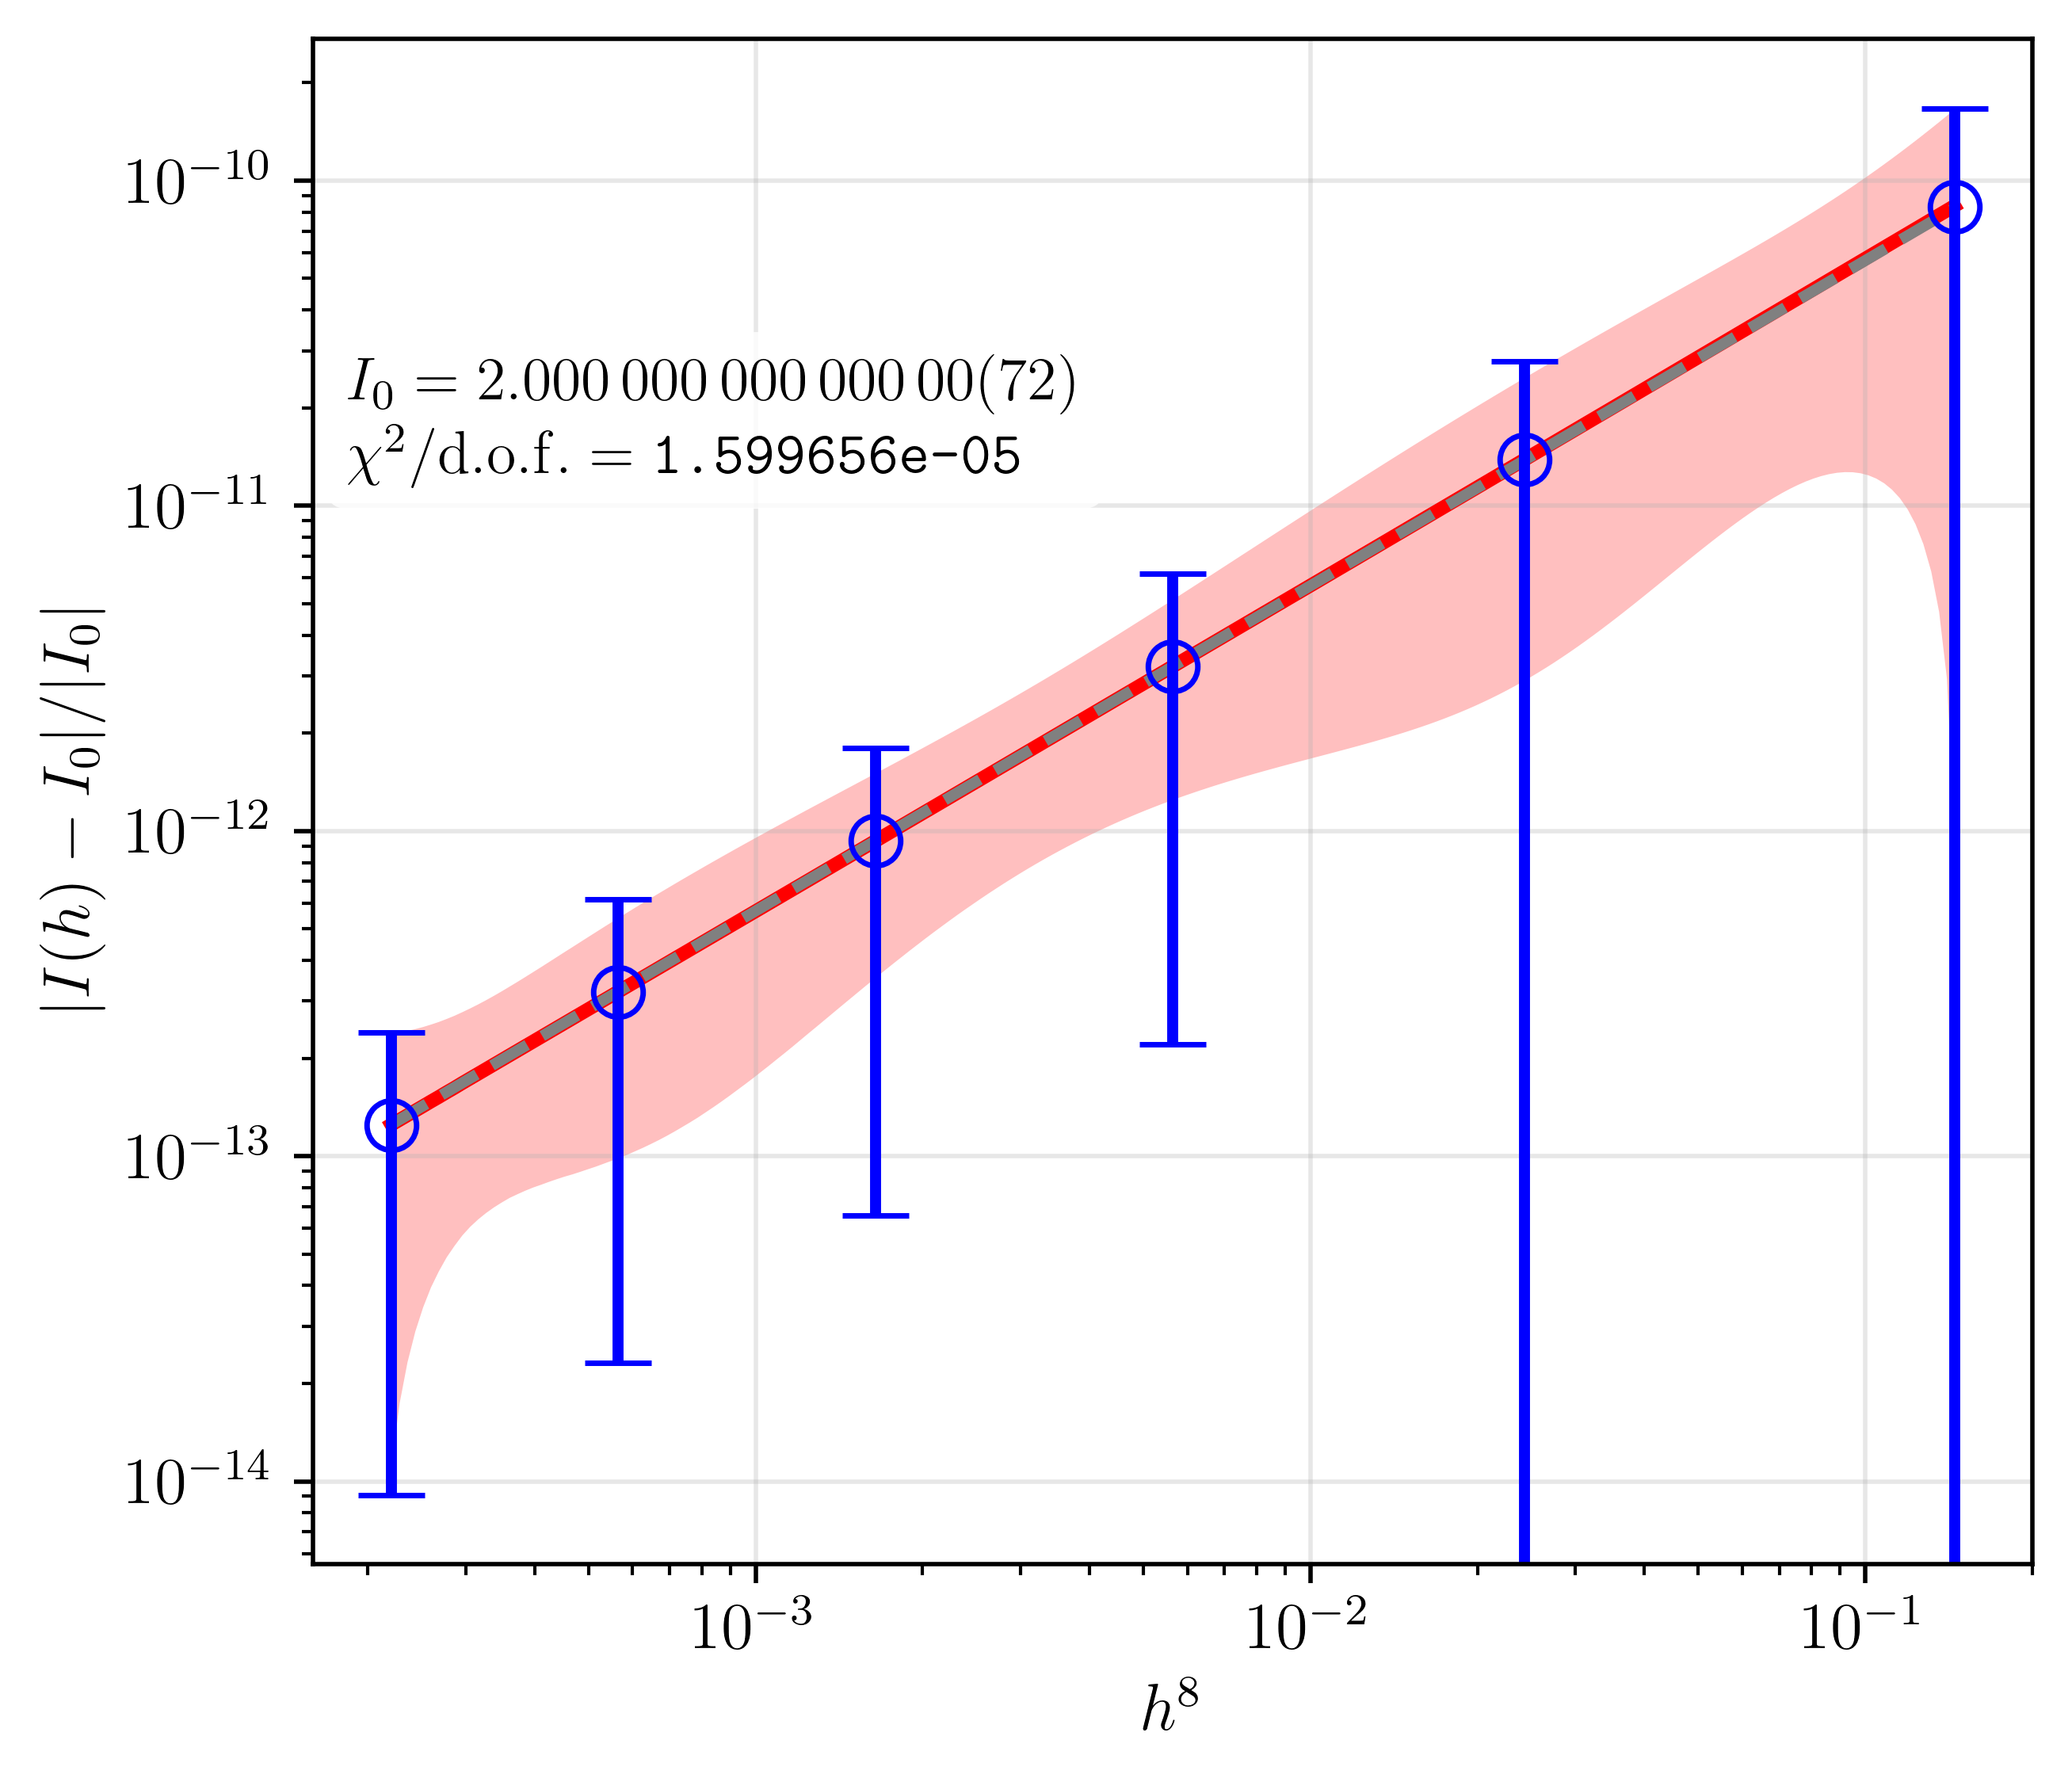

In [8]:
plot_convergence_result(
    run_result_filtered, 
    fit_result_filtered; 
    name="Maranatha_test4",
    figs_dir=".",
    save_file=true
)

## Summary

In this notebook we demonstrated how to rebuild a quadrature
dataset after removing selected resolution points.

Workflow:

1. Generate or identify a saved result file
2. Remove selected `nsamples` using `drop_nsamples_from_file`
3. Load the filtered dataset
4. Inspect the remaining datapoints
5. Perform fitting and convergence analysis again

This workflow is especially useful for testing fit stability
and studying the effect of excluding specific resolutions.